# Combine Tracking Videos into Vertical Stack

This notebook combines multiple tracking videos from different IOU tracker configurations into a single vertically-stacked video for easy comparison.

**Key Features:**
- Videos are stacked vertically (one above the other)
- Each video is cropped to show only the **top 30%** of the frame (focusing on the upper part of the road)
- This creates a wider aspect ratio for each video cell

In [15]:
import cv2 as cv
import numpy as np
from pathlib import Path
import os
import math
from tqdm import tqdm

## 1. Find All Tracking Videos

In [16]:
# Configuration
RESULTS_DIR = Path("../results")
PATTERN = "tracking_iou_finetuned_"  # Pattern to search for
VIDEO_FILENAME = "tracking.avi"
OUTPUT_PATH = Path("../results/tracking_comparison_grid.avi")

# Find all directories matching the pattern
tracking_dirs = sorted([d for d in RESULTS_DIR.iterdir() 
                       if d.is_dir() and d.name.startswith(PATTERN)])

print(f"Found {len(tracking_dirs)} tracking directories:")
for i, d in enumerate(tracking_dirs, 1):
    video_path = d / VIDEO_FILENAME
    if video_path.exists():
        print(f"  {i}. {d.name} ✓")
    else:
        print(f"  {i}. {d.name} ✗ (video not found)")

# Filter only directories with existing videos
video_paths = [(d.name, d / VIDEO_FILENAME) for d in tracking_dirs 
               if (d / VIDEO_FILENAME).exists()]

print(f"\nTotal videos to combine: {len(video_paths)}")

Found 3 tracking directories:
  1. tracking_iou_finetuned_age=2_threshold=0.05 ✓
  2. tracking_iou_finetuned_age=4_threshold=0.05 ✓
  3. tracking_iou_finetuned_age=6_threshold=0.05 ✓

Total videos to combine: 3


## 2. Calculate Grid Layout

In [17]:
def calculate_grid_layout(num_videos):
    """
    Calculate grid layout: always vertical stack (N rows, 1 column).
    Returns (rows, cols)
    """
    if num_videos == 0:
        return (0, 0)
    else:
        # Always stack vertically: N rows, 1 column
        return (num_videos, 1)

num_videos = len(video_paths)
rows, cols = calculate_grid_layout(num_videos)

print(f"Grid layout: {rows} rows × {cols} column (vertical stack)")
print(f"Total cells: {rows * cols} (using {num_videos})")
print(f"Note: Videos will be cropped to show only top 30% of frame")

Grid layout: 3 rows × 1 column (vertical stack)
Total cells: 3 (using 3)
Note: Videos will be cropped to show only top 30% of frame


## 3. Load Video Properties

In [18]:
# Open first video to get properties
if len(video_paths) == 0:
    raise ValueError("No videos found to combine!")

first_video = cv.VideoCapture(str(video_paths[0][1]))
original_width = int(first_video.get(cv.CAP_PROP_FRAME_WIDTH))
original_height = int(first_video.get(cv.CAP_PROP_FRAME_HEIGHT))
fps = first_video.get(cv.CAP_PROP_FPS)
total_frames = int(first_video.get(cv.CAP_PROP_FRAME_COUNT))
first_video.release()

# Apply 30% crop to height
crop_height = int(original_height * 0.30)

print(f"\nOriginal video properties:")
print(f"  Resolution: {original_width}x{original_height}")
print(f"  Cropped to top 30%: {original_width}x{crop_height}")
print(f"  FPS: {fps}")
print(f"  Total frames: {total_frames}")

# Calculate cell size (resize videos to fit in grid)
# Keep aspect ratio and fit within reasonable output size
MAX_OUTPUT_WIDTH = 1920
MAX_OUTPUT_HEIGHT = 1080

cell_width = MAX_OUTPUT_WIDTH // cols
cell_height = MAX_OUTPUT_HEIGHT // rows

# Maintain aspect ratio of CROPPED frame
aspect_ratio = original_width / crop_height
if cell_width / cell_height > aspect_ratio:
    cell_width = int(cell_height * aspect_ratio)
else:
    cell_height = int(cell_width / aspect_ratio)

output_width = cell_width * cols
output_height = cell_height * rows

print(f"\nOutput video properties:")
print(f"  Cell size: {cell_width}x{cell_height}")
print(f"  Grid resolution: {output_width}x{output_height}")
print(f"  FPS: {fps}")


Original video properties:
  Resolution: 1920x1080
  Cropped to top 30%: 1920x324
  FPS: 10.0
  Total frames: 1606

Output video properties:
  Cell size: 1920x324
  Grid resolution: 1920x972
  FPS: 10.0


## 4. Create Combined Video

In [19]:
# Open all video captures
captures = []
labels = []

for name, path in video_paths:
    cap = cv.VideoCapture(str(path))
    if not cap.isOpened():
        print(f"Warning: Could not open {path}")
        continue
    captures.append(cap)
    
    # Extract configuration from folder name
    # Example: tracking_iou_finetuned_age=2_threshold=0.05
    parts = name.replace(PATTERN, "").split("_")
    label_parts = []
    for part in parts:
        if "=" in part:
            key, val = part.split("=")
            label_parts.append(f"{key}={val}")
    label = ", ".join(label_parts) if label_parts else name
    labels.append(label)

print(f"\nOpened {len(captures)} video captures")
for i, (label, (name, _)) in enumerate(zip(labels, video_paths), 1):
    print(f"  {i}. {label}")


Opened 3 video captures
  1. age=2, threshold=0.05
  2. age=4, threshold=0.05
  3. age=6, threshold=0.05


In [20]:
# Create video writer
fourcc = cv.VideoWriter_fourcc(*'XVID')
out = cv.VideoWriter(str(OUTPUT_PATH), fourcc, fps, (output_width, output_height))

if not out.isOpened():
    raise ValueError(f"Could not create output video at {OUTPUT_PATH}")

print(f"\nCreating combined video at {OUTPUT_PATH}...")
print(f"Processing {total_frames} frames...")

# Process frame by frame
for frame_idx in tqdm(range(total_frames), desc="Combining videos", unit="frame"):
    # Create blank canvas
    canvas = np.zeros((output_height, output_width, 3), dtype=np.uint8)
    
    # Read and place each video frame
    for idx, (cap, label) in enumerate(zip(captures, labels)):
        ret, frame = cap.read()
        
        if not ret:
            # If video ended, create a black frame
            frame = np.zeros((original_height, original_width, 3), dtype=np.uint8)
        
        # Crop to top 30% of frame
        crop_height = int(original_height * 0.30)
        frame_cropped = frame[0:crop_height, :]  # Take only top 30%
        
        # Resize cropped frame to cell size
        frame_resized = cv.resize(frame_cropped, (cell_width, cell_height))
        
        # Add label to frame
        label_text = label
        font = cv.FONT_HERSHEY_SIMPLEX
        font_scale = 0.5
        font_thickness = 1
        text_size = cv.getTextSize(label_text, font, font_scale, font_thickness)[0]
        
        # Black background for text
        text_x = 5
        text_y = 20
        cv.rectangle(frame_resized, 
                    (text_x - 2, text_y - text_size[1] - 2),
                    (text_x + text_size[0] + 2, text_y + 2),
                    (0, 0, 0), -1)
        
        # White text
        cv.putText(frame_resized, label_text, (text_x, text_y),
                  font, font_scale, (255, 255, 255), font_thickness)
        
        # Calculate position in grid
        row = idx // cols
        col = idx % cols
        
        # Place frame in canvas
        y_start = row * cell_height
        y_end = y_start + cell_height
        x_start = col * cell_width
        x_end = x_start + cell_width
        
        canvas[y_start:y_end, x_start:x_end] = frame_resized
    
    # Write frame to output
    out.write(canvas)

# Release resources
for cap in captures:
    cap.release()
out.release()

print(f"\n✅ Combined video saved to: {OUTPUT_PATH}")
print(f"   Resolution: {output_width}x{output_height}")
print(f"   Duration: {total_frames} frames @ {fps} FPS = {total_frames/fps:.2f} seconds")
print(f"   Layout: {rows} videos stacked vertically (top 30% of each video)")


Creating combined video at ../results/tracking_comparison_grid.avi...
Processing 1606 frames...


Combining videos: 100%|██████████| 1606/1606 [00:34<00:00, 46.59frame/s]


✅ Combined video saved to: ../results/tracking_comparison_grid.avi
   Resolution: 1920x972
   Duration: 1606 frames @ 10.0 FPS = 160.60 seconds
   Layout: 3 videos stacked vertically (top 30% of each video)


## 5. (Optional) Display Grid Layout Preview


📊 Grid layout preview saved to: ../results/grid_layout_preview.png


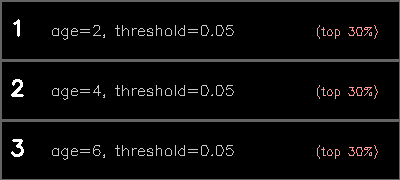

In [21]:
# Create a simple layout visualization (vertical stack)
# Make it wider to show the aspect ratio change
viz_width = 400
viz_height_per_cell = 60

layout_viz = np.zeros((rows * viz_height_per_cell, viz_width, 3), dtype=np.uint8)

for idx, label in enumerate(labels):
    y_start = idx * viz_height_per_cell
    
    # Draw cell border
    cv.rectangle(layout_viz, 
                (0, y_start), 
                (viz_width, y_start + viz_height_per_cell),
                (100, 100, 100), 2)
    
    # Add label number
    cv.putText(layout_viz, f"{idx+1}", 
              (10, y_start + 35),
              cv.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    
    # Add config name
    cv.putText(layout_viz, label, 
              (50, y_start + 35),
              cv.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1)
    
    # Add note about crop
    cv.putText(layout_viz, "(top 30%)", 
              (viz_width - 85, y_start + 35),
              cv.FONT_HERSHEY_SIMPLEX, 0.4, (150, 150, 255), 1)

# Save layout visualization
layout_path = OUTPUT_PATH.parent / "grid_layout_preview.png"
cv.imwrite(str(layout_path), layout_viz)
print(f"\n📊 Grid layout preview saved to: {layout_path}")

# Display in notebook (if running in Jupyter)
try:
    from IPython.display import Image, display
    display(Image(filename=str(layout_path)))
except:
    print("(Preview image created but cannot display in this environment)")